# ปัจจัยที่สัมพันธ์กับ PM2.5 ในหาดใหญ่ (2021–2025)

สำรวจข้อมูลรายวันจากสถานี 44T ด้วยกราฟและสถิติเชิงพรรณนา เน้นความสัมพันธ์และรูปแบบตามเวลา ผลเชิงสหสัมพันธ์ไม่ยืนยันเหตุและผล

**วิธีใช้:** รันเซลล์จากบนลงล่าง โดยเปิด Jupyter จากโฟลเดอร์โปรเจกต์หรือปรับ `DATA_PATH` ในเซลล์ตั้งค่าได้ กราฟจะถูกบันทึกใน `figures/`


## 0. เตรียม environment

### Google Colab

เปิด notebook ใน Colab แล้วรันเซลล์ถัดไป ระบบจะติดตั้งแพ็กเกจที่ยังขาดและให้เลือกอัปโหลด `data_2021-2025.xlsx` จากเครื่อง

### รันในเครื่อง

```bash
uv init --bare  # ทำครั้งเดียว ถ้ายังไม่มี pyproject.toml
uv add pandas openpyxl numpy matplotlib seaborn scipy statsmodels scikit-learn shap windrose jupyterlab
uv run jupyter lab
```


In [ ]:
# ตรวจว่าเปิด notebook บน Google Colab หรือไม่
from pathlib import Path
import importlib.util
import subprocess
import sys

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

COLAB_DATA_PATH = None
if IN_COLAB:
    required = {"pandas":"pandas", "numpy":"numpy", "matplotlib":"matplotlib", "requests":"requests", "openpyxl":"openpyxl", "seaborn":"seaborn", "scipy":"scipy", "statsmodels":"statsmodels", "sklearn":"scikit-learn", "shap":"shap", "windrose":"windrose"}
    missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

    from google.colab import files
    print("เลือกไฟล์ assets/data_2021-2025.xlsx เพื่ออัปโหลด")
    uploaded = files.upload()
    candidates = [name for name in uploaded if name.lower().endswith(".xlsx")]
    preferred = "data_2021-2025.xlsx"
    if preferred in candidates:
        chosen = preferred
    elif candidates:
        chosen = candidates[0]
    else:
        raise FileNotFoundError("อัปโหลดไฟล์ Excel (.xlsx) เพื่อเริ่มวิเคราะห์")
    COLAB_DATA_PATH = Path("/content") / chosen
    print("ใช้ไฟล์:", COLAB_DATA_PATH)
else:
    print("ไม่ได้เปิดใน Colab; ใช้ไฟล์จาก assets/ ของโปรเจกต์")


In [ ]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import spearmanr, kruskal

warnings.filterwarnings("ignore", category=FutureWarning)

# หาไฟล์จาก cwd หรือ parent เพื่อให้รันได้ทั้งจาก root และ notebooks/
_candidates = [Path.cwd() / "assets/data_2021-2025.xlsx", Path.cwd().parent / "assets/data_2021-2025.xlsx"]
DATA_PATH = COLAB_DATA_PATH if IN_COLAB and COLAB_DATA_PATH is not None else next((p for p in _candidates if p.exists()), _candidates[0])
FIGURES = Path.cwd() / "figures" if IN_COLAB else DATA_PATH.parent.parent / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# ตั้ง seaborn theme ก่อน เพราะการตั้ง theme อาจเปลี่ยนค่า font.family กลับเป็น sans-serif
sns.set_theme(style="whitegrid", context="notebook")

# เลือกฟอนต์ไทยที่ติดตั้งอยู่; ถ้าไม่มีให้ดาวน์โหลด Noto Sans Thai มาใช้เฉพาะกับ Matplotlib
from matplotlib import font_manager
from urllib.request import urlretrieve
_installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
_thai_font_name = next((name for name in ["Noto Sans Thai", "Tahoma", "Leelawadee UI"] if name in _installed_fonts), None)
if _thai_font_name is None:
    _font_dir = Path.home() / ".cache" / "matplotlib" / "thai-fonts"
    _font_dir.mkdir(parents=True, exist_ok=True)
    _font_path = _font_dir / "NotoSansThai.ttf"
    _font_url = "https://raw.githubusercontent.com/google/fonts/main/ofl/notosansthai/NotoSansThai%5Bwdth%2Cwght%5D.ttf"
    try:
        if not _font_path.exists():
            urlretrieve(_font_url, _font_path)
        font_manager.fontManager.addfont(str(_font_path))
        _thai_font_name = font_manager.FontProperties(fname=str(_font_path)).get_name()
        print(f"ใช้ฟอนต์ภาษาไทย: {_thai_font_name}")
    except Exception as exc:
        warnings.warn(f"ดาวน์โหลดฟอนต์ไทยไม่สำเร็จ ({exc}); ตัวอักษรไทยในกราฟอาจแสดงไม่ครบ")
        _thai_font_name = None
if _thai_font_name:
    # กำหนดทั้ง family และ sans-serif หลัง set_theme เพื่อไม่ให้ seaborn เปลี่ยนกลับเป็น DejaVu Sans
    plt.rcParams["font.family"] = [_thai_font_name]
    plt.rcParams["font.sans-serif"] = [_thai_font_name, "DejaVu Sans"]
    print("Matplotlib font:", _thai_font_name)
else:
    print("ไม่พบฟอนต์ไทย; กราฟอาจแสดงตัวอักษรเป็นกล่อง")

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 200, "axes.spines.top": False, "axes.spines.right": False})

AQI_COLORS = {"ฟ้า":"#56B4E9", "เขียว":"#009E73", "เหลือง":"#F0E442", "ส้ม":"#E69F00", "แดง":"#D55E00"}
PALETTE = ["#4477AA", "#66CCEE", "#228833", "#CCBB44", "#EE6677", "#AA3377"]

def savefig(fig, filename):
    fig.tight_layout()
    fig.savefig(FIGURES / filename, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"บันทึก: {FIGURES / filename}")

print("ข้อมูล:", DATA_PATH.resolve())
print("โฟลเดอร์รูป:", FIGURES.resolve())


## 1. โหลดข้อมูลและเกณฑ์ TH AQI

เก็บชื่อเดิมไว้ใน `COLUMN_LABELS` เพื่อใช้ทำป้ายกราฟภาษาไทย ส่วนชีต `Summary` ในไฟล์ต้นทางไม่ได้ใช้คำนวณซ้ำ


In [ ]:
raw = pd.read_excel(DATA_PATH, sheet_name="Data")
bp_raw = pd.read_excel(DATA_PATH, sheet_name="BP", header=3)
COLUMN_LABELS = {
    "date":"วันที่", "pm25":"PM2.5 (มкг./ลบ.ม.)", "aqi":"AQI", "aqi_level":"ระดับคุณภาพอากาศ",
    "year":"ปี", "month":"เดือน", "wind_max":"ลมสูงสุด (km/h)", "wind_gust":"ลมกระโชก (km/h)",
    "wind_dir":"ทิศลม (°)", "rain_model":"ฝน model (มม.)", "rain_obs":"ปริมาณน้ำฝน (มม.)", "day_type":"ประเภทวัน",
    "wind_sin":"ทิศลม sin", "wind_cos":"ทิศลม cos", "rain_lag1":"ฝนย้อนหลัง 1 วัน", "rain_lag2":"ฝนย้อนหลัง 2 วัน",
    "rain_lag3":"ฝนย้อนหลัง 3 วัน", "rain_3d_sum":"ฝนสะสม 3 วัน", "wind_max":"ลมสูงสุด (km/h)"
}
# ผูกชื่อคอลัมน์ตามตำแหน่ง header จาก workbook เพื่อเลี่ยงความต่างของตัวอักษรหน่วย
expected = ["วันที่", "PM2.5 (มкг./ลบ.ม.)", "AQI", "ระดับคุณภาพอากาศ", "ปี", "เดือน", "ลมสูงสุด (km/h)", "ลมกระโชก (km/h)", "ทิศลม (°)", "ฝน model (มม.)", "ปริมาณน้ำฝน (มม.)", "ประเภทวัน"]
rename = dict(zip(raw.columns, ["date","pm25","aqi","aqi_level","year","month","wind_max","wind_gust","wind_dir","rain_model","rain_obs","day_type"]))
df = raw.rename(columns=rename).copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
for c in ["pm25","aqi","year","month","wind_max","wind_gust","wind_dir","rain_model","rain_obs"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

# ใช้ตำแหน่ง 0, 1, 5, 6 จากชีต BP (C_low, C_high, ชื่อระดับ, สี)
bp = bp_raw.iloc[:, [0,1,5,6]].copy()
bp.columns = ["pm25_low","pm25_high","aqi_level","color_name"]
bp = bp.dropna(subset=["pm25_low","pm25_high"])
bp["pm25_low"] = pd.to_numeric(bp.pm25_low, errors="coerce")
bp["pm25_high"] = pd.to_numeric(bp.pm25_high, errors="coerce")
print("ขนาดข้อมูล:", df.shape, "ช่วงวันที่:", df.date.min().date(), "ถึง", df.date.max().date())
display(df.head(), bp)

## 2. ตรวจคุณภาพข้อมูลและสร้างตัวแปร

ค่าที่หายคงเป็น `NaN` ไว้ เราไม่ได้เติมค่าหรือใช้ข้อมูลอนาคต ข้อมูลฝนหลักใช้ค่าที่สังเกตจริง (`rain_obs`)


In [ ]:
missing = df[["pm25","aqi","rain_obs","wind_max","wind_dir"]].isna().sum().rename("จำนวนค่าว่าง").to_frame()
print("จำนวนแถว:", len(df), "จำนวนวันที่ไม่ซ้ำ:", df.date.nunique())
display(missing)
# แสดงช่วงวันที่ที่ PM2.5/AQI หาย โดยรวมวันที่ติดกันเป็นช่วงเดียว
miss_dates = df.loc[df.pm25.isna() | df.aqi.isna(), "date"].dropna().sort_values()
blocks=[]
for d in miss_dates:
    if not blocks or (d - blocks[-1][-1]).days > 1: blocks.append([d])
    else: blocks[-1].append(d)
print("ช่วงวันที่ PM2.5 หรือ AQI หาย:")
for b in blocks: print(f"{b[0].date()} ถึง {b[-1].date()} ({len(b)} วัน)")

fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=df, x="rain_model", y="rain_obs", alpha=.35, s=18, ax=ax, color=PALETTE[0])
ax.set(xlabel="ฝนจาก model (มม.)", ylabel="ฝนวัดจริง (มม.)", title="เปรียบเทียบค่าฝนสองแหล่ง")
savefig(fig, "02_rain_sources.png")
print("Spearman ระหว่างฝน model กับฝนวัดจริง:", spearmanr(df.rain_model, df.rain_obs, nan_policy="omit"))

# องศาลมเป็นข้อมูลวงกลม; lag ใช้ได้เฉพาะวันที่ต่อเนื่องกัน
deg = np.deg2rad(df.wind_dir)
df["wind_sin"], df["wind_cos"] = np.sin(deg), np.cos(deg)
df["wind_sector"] = pd.cut((df.wind_dir + 22.5) % 360, bins=np.arange(0, 361, 45), labels=["N","NE","E","SE","S","SW","W","NW"], right=False)
for lag in range(1,4):
    shifted = df.rain_obs.shift(lag)
    contiguous = df.date.diff().dt.days.eq(1).rolling(lag, min_periods=lag).sum().eq(lag)
    df[f"rain_lag{lag}"] = shifted.where(contiguous.to_numpy())
df["rain_3d_sum"] = df[["rain_lag1","rain_lag2","rain_lag3"]].sum(axis=1, min_count=1)
df["rain_bin"] = pd.cut(df.rain_obs, [-0.001,0,5,20,np.inf], labels=["0",">0–5",">5–20",">20"], include_lowest=True)
df["wind_bin"] = pd.qcut(df.wind_max, 4, labels=["Q1 อ่อน","Q2","Q3","Q4 แรง"], duplicates="drop")
season_map = {12:"มรสุมตะวันออกเฉียงเหนือ",1:"มรสุมตะวันออกเฉียงเหนือ",2:"แล้ง",3:"แล้ง",4:"แล้ง",5:"มรสุมตะวันตกเฉียงใต้",6:"มรสุมตะวันตกเฉียงใต้",7:"มรสุมตะวันตกเฉียงใต้",8:"มรสุมตะวันตกเฉียงใต้",9:"มรสุมตะวันตกเฉียงใต้",10:"มรสุมตะวันตกเฉียงใต้",11:"มรสุมตะวันออกเฉียงเหนือ"}
df["season"] = df.month.map(season_map)
df["pm25_roll7"] = df.pm25.rolling(7, min_periods=4).mean()
df["pm25_roll30"] = df.pm25.rolling(30, min_periods=15).mean()
display(df[["date","pm25","rain_obs","rain_lag1","rain_3d_sum","wind_sector","season"]].head(10))


,pm25
count,1804.00
mean,14.93
std,5.26
min,5.50
25%,11.30
50%,14.30
75%,18.00
max,44.40


/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 80 (P) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 77 (M) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipy

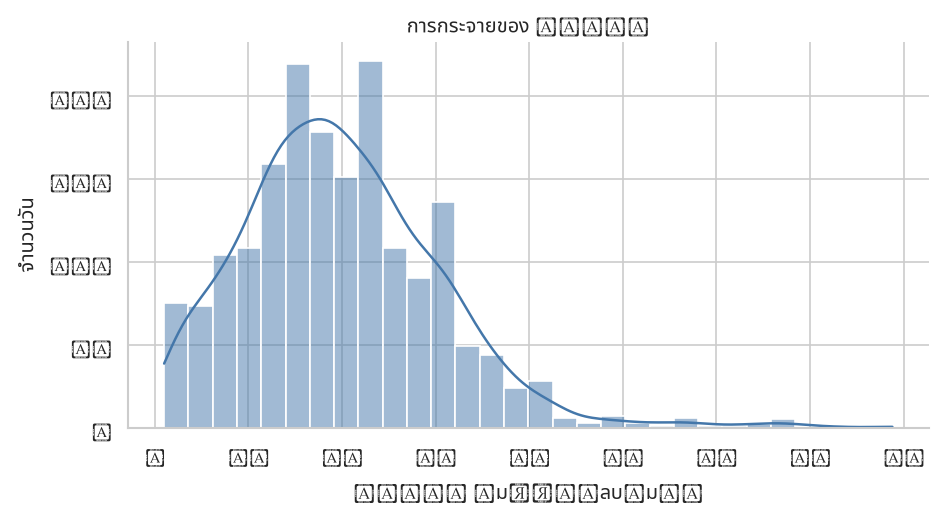

บันทึก: /home/saktanuthpeak/art_of_com/figures/02_pm25_distribution.png


In [9]:
display(df["pm25"].describe().to_frame().round(2))
fig, ax = plt.subplots(figsize=(8,4.5))
sns.histplot(df.pm25.dropna(), bins=30, kde=True, color=PALETTE[0], ax=ax)
ax.set(xlabel="PM2.5 (มкг./ลบ.ม.)", ylabel="จำนวนวัน", title="การกระจายของ PM2.5")
savefig(fig, "02_pm25_distribution.png")


## 3. ภาพรวม PM2.5


/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 54 (6) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 80 (P) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipy

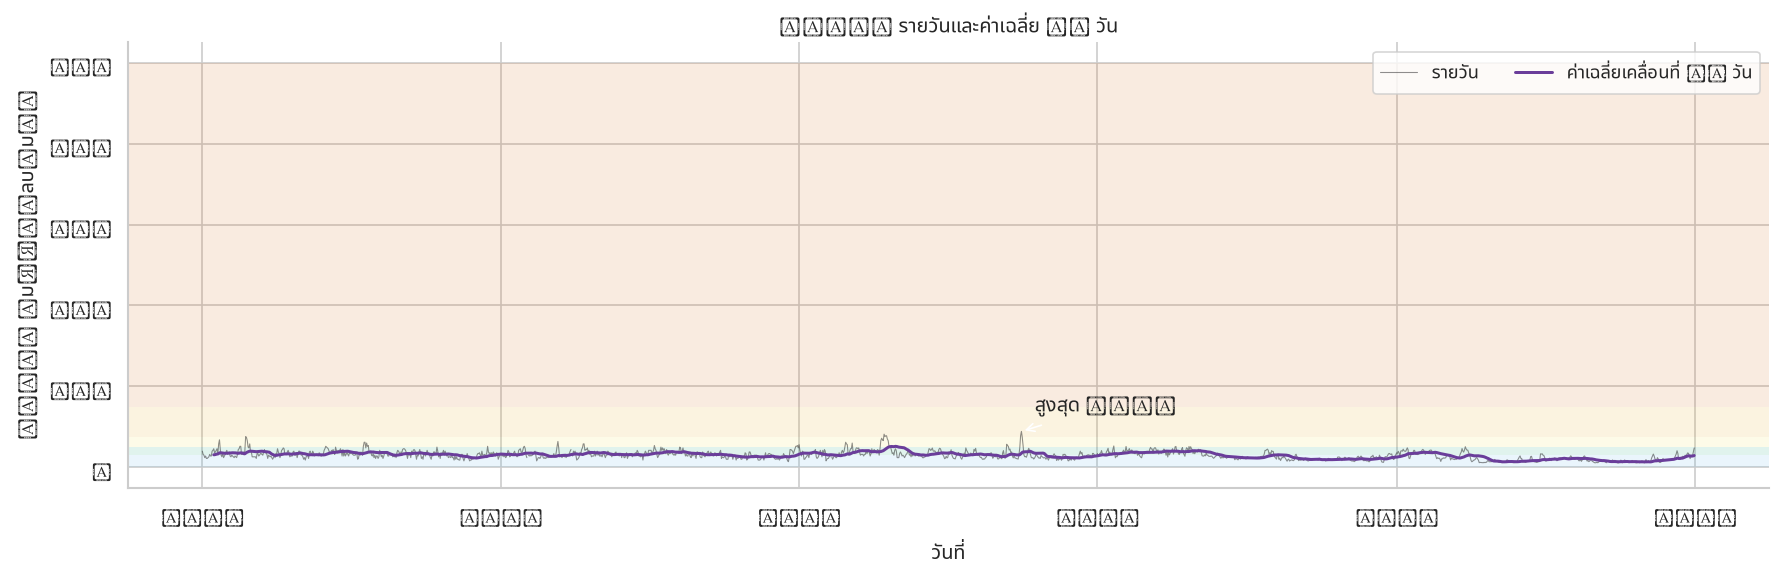

/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 54 (6) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 56 (8) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipy

บันทึก: /home/saktanuthpeak/art_of_com/figures/03_1_pm25_timeseries.png


/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52 (4) missing from f

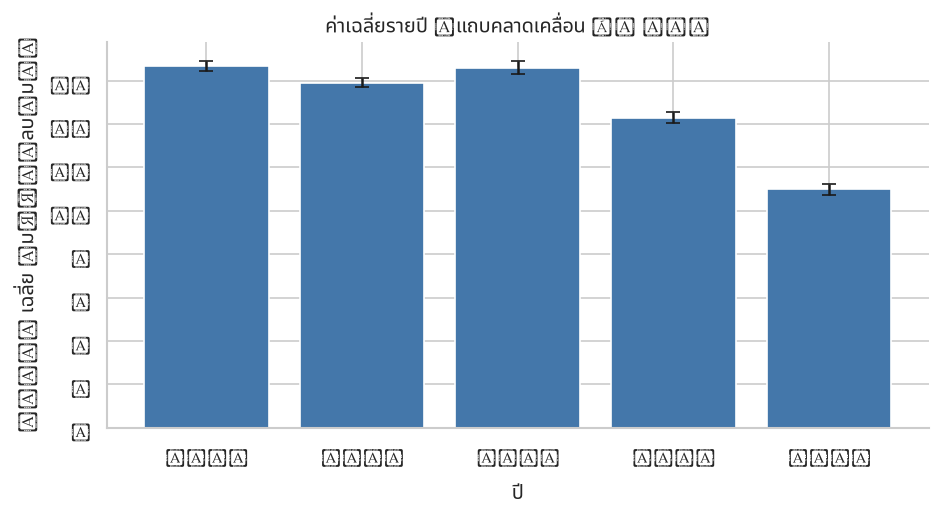

/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.canvas.draw()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.canvas.draw()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.canvas.draw()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.canvas.draw()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Thai.
  fig.canvas.draw()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: Use

บันทึก: /home/saktanuthpeak/art_of_com/figures/03_2_annual_mean.png


/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52 (4) missing from f

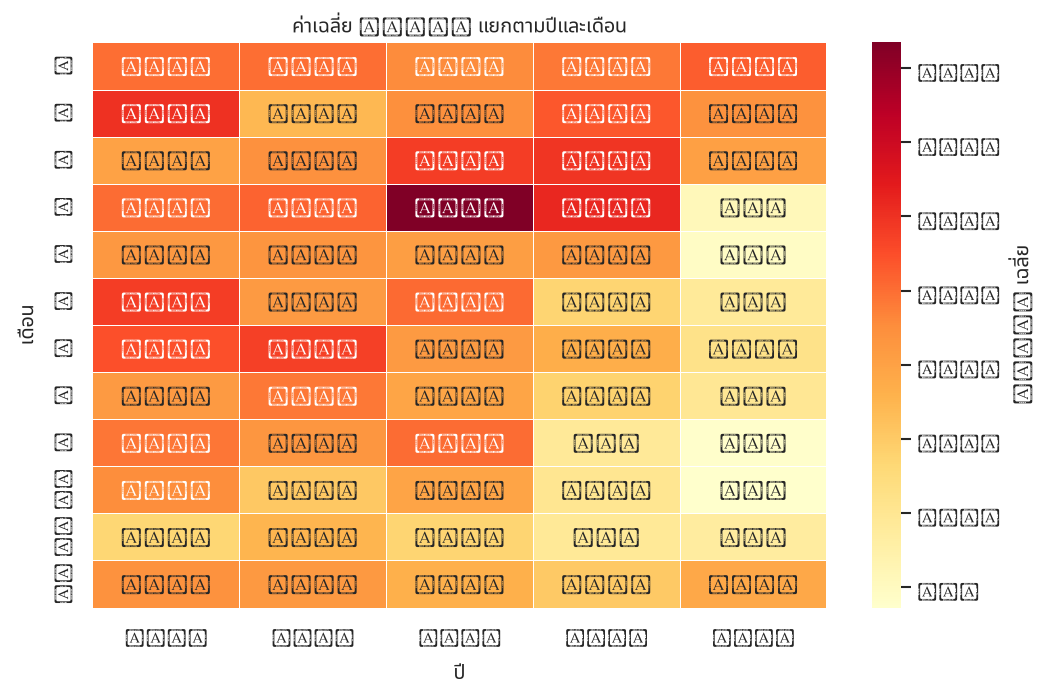

บันทึก: /home/saktanuthpeak/art_of_com/figures/03_3_month_year_heatmap.png


/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 54 (6) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 55 (7) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 56 (8) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipy

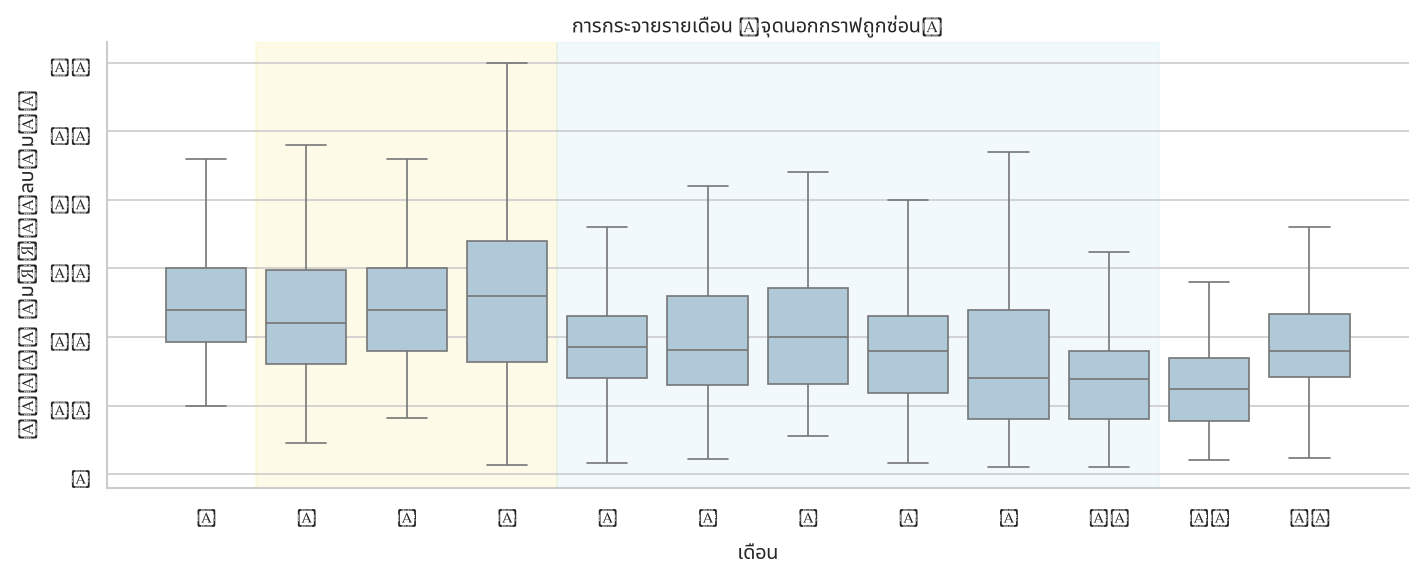

บันทึก: /home/saktanuthpeak/art_of_com/figures/03_4_month_boxplot.png


/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 80 (P) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 77 (M) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipy

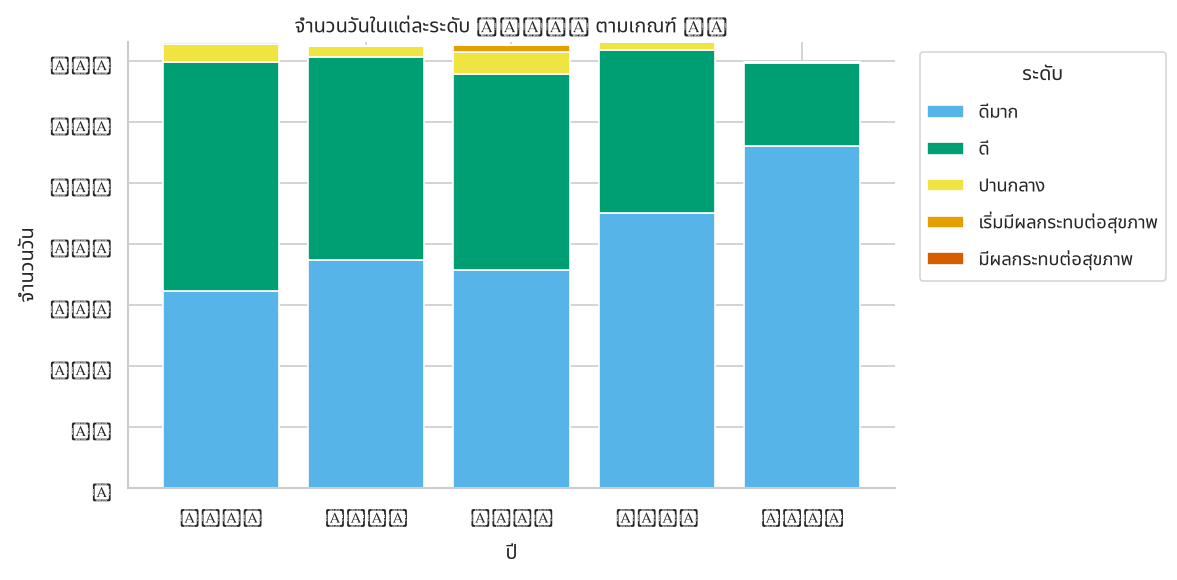

บันทึก: /home/saktanuthpeak/art_of_com/figures/03_5_aqi_days_by_year.png


,year,mean,std,count,se
0,2021,16.68,4.57,365,0.24
1,2022,15.92,4.03,362,0.21
2,2023,16.61,5.90,363,0.31
3,2024,14.30,4.66,365,0.24
4,2025,10.99,4.76,349,0.25


In [10]:
fig, ax = plt.subplots(figsize=(15,5))
for _, r in bp.iterrows(): ax.axhspan(r.pm25_low, r.pm25_high, color=AQI_COLORS.get(str(r.color_name), "#eeeeee"), alpha=.12, lw=0)
ax.plot(df.date, df.pm25, color="#333333", lw=.65, alpha=.55, label="รายวัน")
ax.plot(df.date, df.pm25_roll30, color="#6A3D9A", lw=1.8, label="ค่าเฉลี่ยเคลื่อนที่ 30 วัน")
peak = df.loc[df.pm25.idxmax()]
ax.annotate(f"สูงสุด {peak.pm25:.1f}", (peak.date, peak.pm25), xytext=(8,12), textcoords="offset points", arrowprops={"arrowstyle":"->"})
ax.set(xlabel="วันที่", ylabel="PM2.5 (มкг./ลบ.ม.)", title="PM2.5 รายวันและค่าเฉลี่ย 30 วัน")
ax.legend(ncol=2); ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
savefig(fig, "03_1_pm25_timeseries.png")

annual = df.groupby("year").pm25.agg(["mean","std","count"]).reset_index()
annual["se"] = annual["std"] / np.sqrt(annual["count"])
fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(annual.year.astype(int), annual["mean"], yerr=annual.se, capsize=4, color=PALETTE[0])
ax.set(xticks=annual.year.astype(int), xlabel="ปี", ylabel="PM2.5 เฉลี่ย (มкг./ลบ.ม.)", title="ค่าเฉลี่ยรายปี (แถบคลาดเคลื่อน ±1 SE)")
savefig(fig, "03_2_annual_mean.png")

monthly = df.pivot_table(index="month", columns="year", values="pm25", aggfunc="mean")
fig, ax = plt.subplots(figsize=(9,6))
sns.heatmap(monthly, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.5, ax=ax, cbar_kws={"label":"PM2.5 เฉลี่ย"})
ax.set(xlabel="ปี", ylabel="เดือน", title="ค่าเฉลี่ย PM2.5 แยกตามปีและเดือน")
savefig(fig, "03_3_month_year_heatmap.png")

fig, ax = plt.subplots(figsize=(12,5))
sns.boxplot(data=df, x="month", y="pm25", order=range(1,13), showfliers=False, color="#a8cbe0", ax=ax)
ax.axvspan(.5,3.5,color="#F0E442",alpha=.12,zorder=0)  # ก.พ.–เม.ย.
ax.axvspan(3.5,9.5,color="#56B4E9",alpha=.08,zorder=0)  # พ.ค.–ต.ค.
ax.set(xlabel="เดือน", ylabel="PM2.5 (มкг./ลบ.ม.)", title="การกระจายรายเดือน (จุดนอกกราฟถูกซ่อน)")
savefig(fig, "03_4_month_boxplot.png")

# จัดระดับ AQI ตาม BP ด้วยค่า PM2.5 เพื่อให้ใช้เกณฑ์เดียวกับชีตอ้างอิง
def classify_pm25(v):
    if pd.isna(v): return np.nan
    row = bp[(bp.pm25_low <= v) & (bp.pm25_high >= v)]
    return row.aqi_level.iloc[0] if len(row) else bp.iloc[-1].aqi_level
df["aqi_level_bp"] = df.pm25.map(classify_pm25)
levels = bp.aqi_level.tolist()
counts = pd.crosstab(df.year, df.aqi_level_bp).reindex(columns=levels, fill_value=0)
fig, ax = plt.subplots(figsize=(10,5)); bottom=np.zeros(len(counts))
for _, r in bp.iterrows():
    level=r.aqi_level
    if level in counts:
        ax.bar(counts.index.astype(int), counts[level], bottom=bottom, color=AQI_COLORS.get(str(r.color_name),"#999999"), label=level)
        bottom += counts[level].to_numpy()
ax.set(xticks=counts.index.astype(int), xlabel="ปี", ylabel="จำนวนวัน", title="จำนวนวันในแต่ละระดับ PM2.5 ตามเกณฑ์ BP"); ax.legend(title="ระดับ", bbox_to_anchor=(1.02,1), loc="upper left")
savefig(fig, "03_5_aqi_days_by_year.png")
display(annual.round(2))


## 4. ความสัมพันธ์กับปัจจัยแต่ละตัว

ใช้ Spearman เพื่อลดผลจากการกระจายเบ้ของฝน ไม่ใส่ AQI ที่คำนวณจาก PM2.5, ปี, เดือน หรือองศาทิศลมโดยตรง


/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 80 (P) missing from font(s) Noto Sans Thai.
  fig.canvas.draw()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 77 (M) missing from font(s) Noto Sans Thai.
  fig.canvas.draw()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.canvas.draw()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 46 (.) missing from font(s) Noto Sans Thai.
  fig.canvas.draw()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.canvas.draw()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/seaborn/utils.py:61: Use

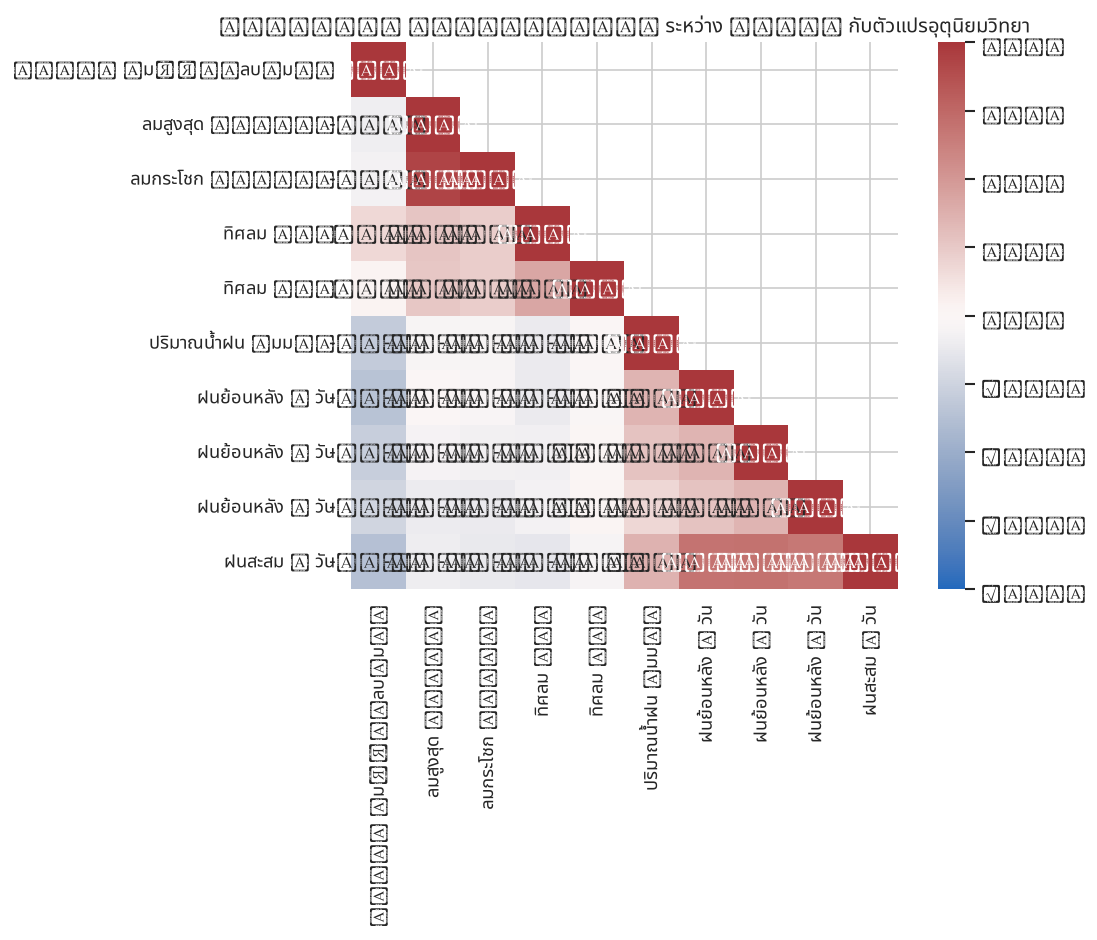

บันทึก: /home/saktanuthpeak/art_of_com/figures/04_1_spearman_heatmap.png


,ตัวแปร,Spearman r,p-value,n,label
8,rain_3d_sum,-0.3675,0.0000,1803,ฝนสะสม 3 วัน
5,rain_lag1,-0.3520,0.0000,1803,ฝนย้อนหลัง 1 วัน
4,rain_obs,-0.3018,0.0000,1804,ปริมาณน้ำฝน (มม.)
6,rain_lag2,-0.2870,0.0000,1802,ฝนย้อนหลัง 2 วัน
7,rain_lag3,-0.2360,0.0000,1801,ฝนย้อนหลัง 3 วัน
0,wind_max,-0.0936,0.0001,1804,ลมสูงสุด (km/h)
1,wind_gust,-0.0636,0.0069,1804,ลมกระโชก (km/h)
3,wind_cos,0.0335,0.1545,1804,ทิศลม cos
2,wind_sin,0.1774,0.0000,1804,ทิศลม sin


/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 46 (.) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 83 (S) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Thai.
  fig.tight_l

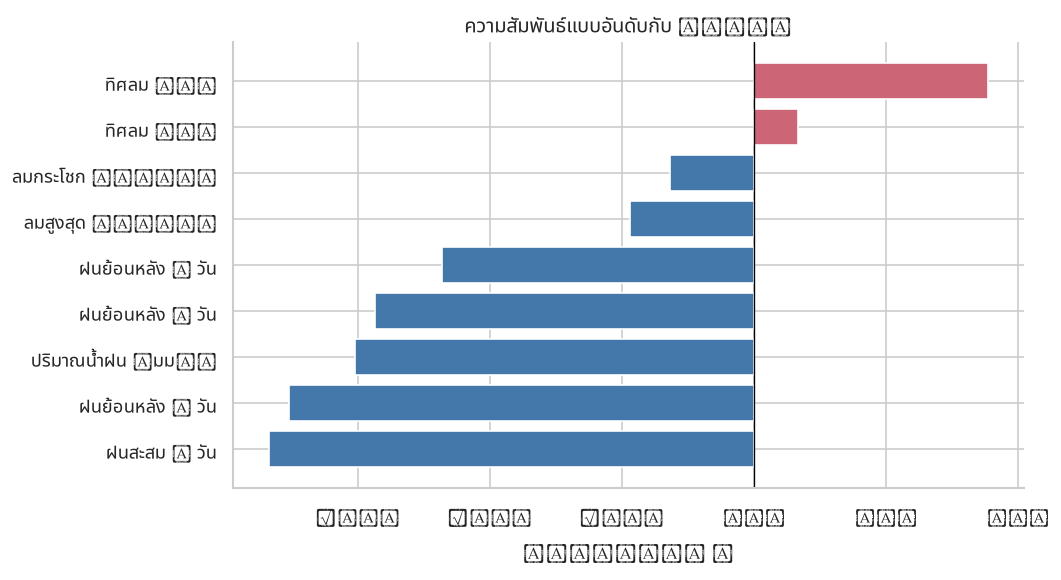

บันทึก: /home/saktanuthpeak/art_of_com/figures/04_2_factor_correlations.png


/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 62 (>) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 40 (() missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 46 (.) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 41 ()) missing from font(s) Noto Sans Thai.
  fig.tight_layou

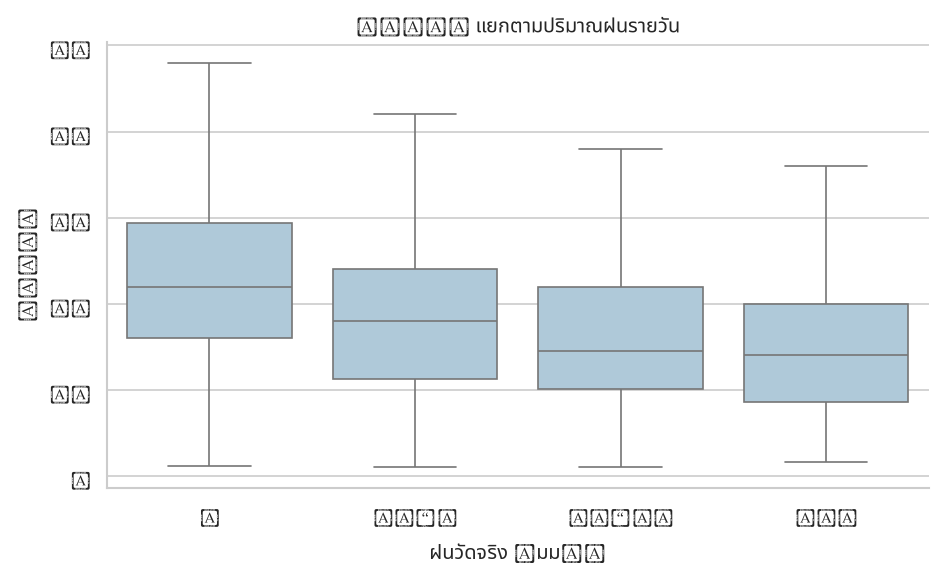

บันทึก: /home/saktanuthpeak/art_of_com/figures/04_3_rain_boxplot.png


/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 81 (Q) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 40 (() missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 113 (q) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 117 (u) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/i

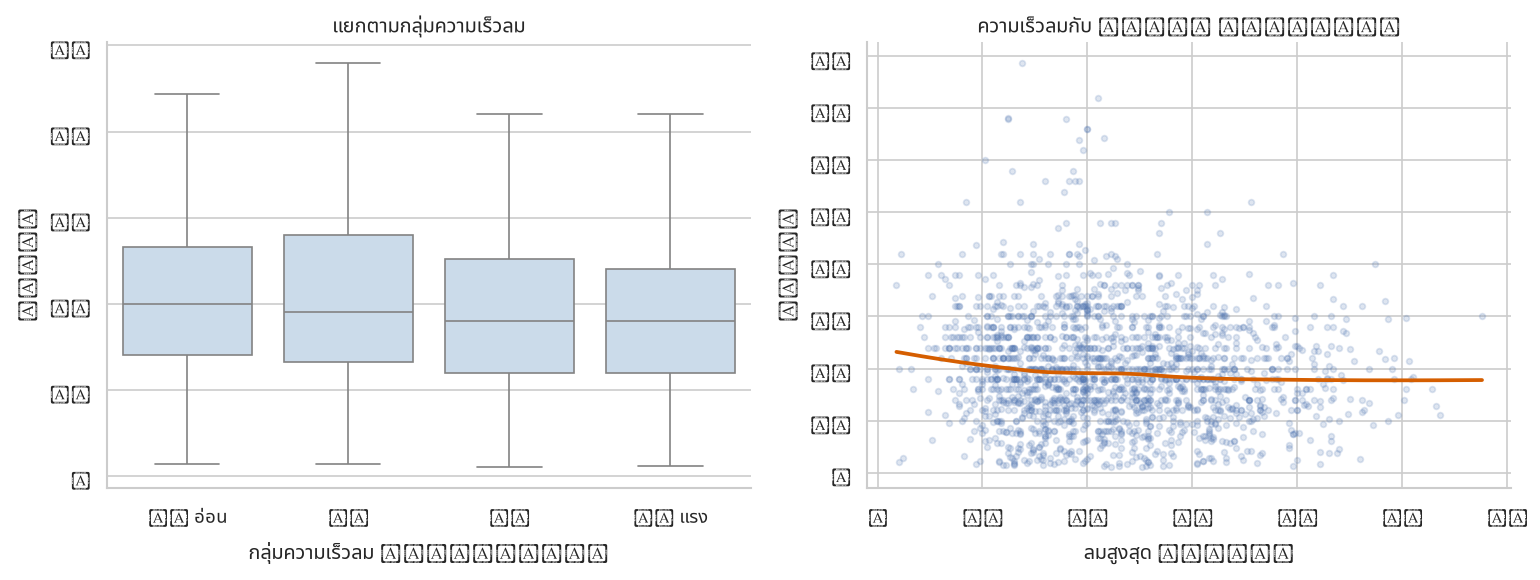

บันทึก: /home/saktanuthpeak/art_of_com/figures/04_4_wind_relationship.png


In [11]:
corr_cols = ["pm25","wind_max","wind_gust","wind_sin","wind_cos","rain_obs","rain_lag1","rain_lag2","rain_lag3","rain_3d_sum"]
corr = df[corr_cols].corr(method="spearman", min_periods=30)
mask=np.triu(np.ones_like(corr,dtype=bool),k=1)
corr_labels=corr.rename(index=COLUMN_LABELS,columns=COLUMN_LABELS)
fig, ax=plt.subplots(figsize=(10,8)); sns.heatmap(corr_labels, mask=mask, annot=True, fmt=".2f", center=0, cmap="vlag", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Spearman correlation ระหว่าง PM2.5 กับตัวแปรอุตุนิยมวิทยา")
savefig(fig,"04_1_spearman_heatmap.png")

rows=[]
for c in corr_cols[1:]:
    d=df[["pm25",c]].dropna()
    r,p=spearmanr(d.pm25,d[c]) if len(d)>2 else (np.nan,np.nan)
    rows.append({"ตัวแปร":c,"Spearman r":r,"p-value":p,"n":len(d)})
cor_table=pd.DataFrame(rows).sort_values("Spearman r")
cor_table["label"] = cor_table["ตัวแปร"].map(COLUMN_LABELS).fillna(cor_table["ตัวแปร"])
display(cor_table.round(4))
fig, ax=plt.subplots(figsize=(9,5)); colors=["#4477AA" if x<0 else "#CC6677" for x in cor_table["Spearman r"]]
ax.barh(cor_table["label"],cor_table["Spearman r"],color=colors); ax.axvline(0,color="black",lw=.8); ax.set(xlabel="Spearman r",title="ความสัมพันธ์แบบอันดับกับ PM2.5")
savefig(fig,"04_2_factor_correlations.png")

fig, ax=plt.subplots(figsize=(8,5)); sns.boxplot(data=df,x="rain_bin",y="pm25",order=["0",">0–5",">5–20",">20"],showfliers=False,ax=ax,color="#a8cbe0")
ax.set(xlabel="ฝนวัดจริง (มม.)",ylabel="PM2.5",title="PM2.5 แยกตามปริมาณฝนรายวัน"); savefig(fig,"04_3_rain_boxplot.png")

fig, axes=plt.subplots(1,2,figsize=(13,5))
sns.boxplot(data=df,x="wind_bin",y="pm25",showfliers=False,ax=axes[0],color="#c6dbef")
sns.regplot(data=df,x="wind_max",y="pm25",lowess=True,scatter_kws={"alpha":.18,"s":12},line_kws={"color":"#D55E00"},ax=axes[1])
axes[0].set(xlabel="กลุ่มความเร็วลม (quartile)",ylabel="PM2.5",title="แยกตามกลุ่มความเร็วลม")
axes[1].set(xlabel="ลมสูงสุด (km/h)",ylabel="PM2.5",title="ความเร็วลมกับ PM2.5 (LOWESS)")
savefig(fig,"04_4_wind_relationship.png")


TypeError: Dimensions of C (4, 25) should be one smaller than X(25) and Y(5) while using shading='flat' see help(pcolormesh)

/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/events.py:101: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  func(*args, **kwargs)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/events.py:101: UserWarning: Glyph 176 (\N{DEGREE SIGN}) missing from font(s) Noto Sans Thai.
  func(*args, **kwargs)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/events.py:101: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Thai.
  func(*args, **kwargs)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/events.py:101: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  func(*args, **kwargs)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/events.py:101: UserWarning: Glyph 57 (9) missing from font(s) Noto Sans Thai.
  func(*args, **kwargs)
/home/saktanuthpeak/art_of_com

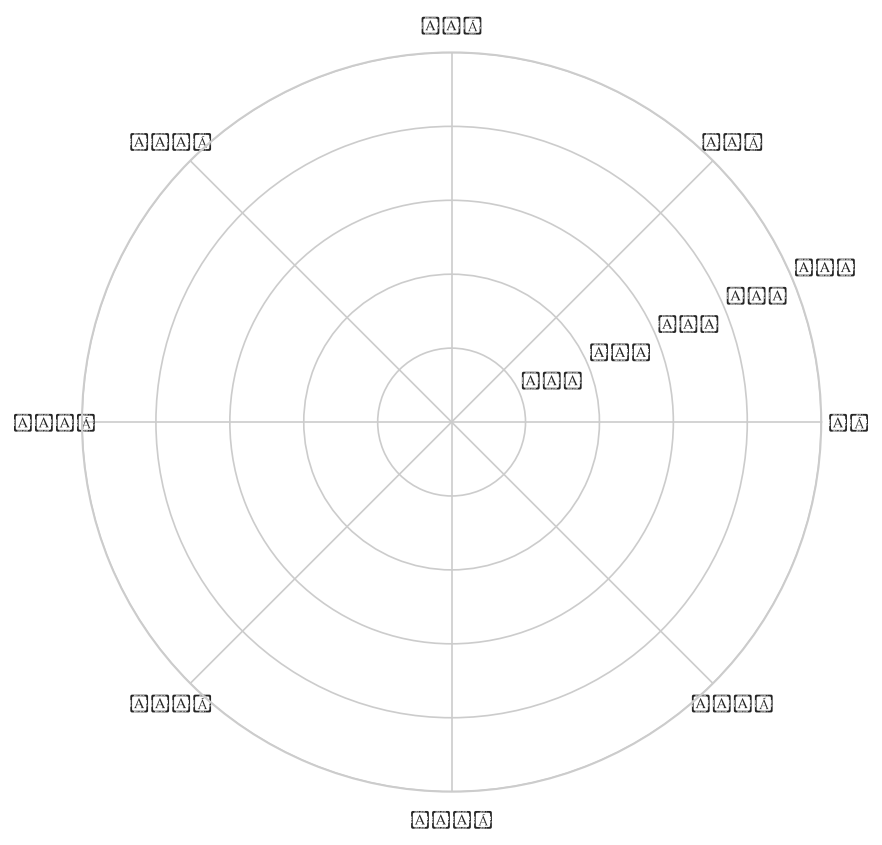

In [12]:
# Polar binning: มุมคือทิศลม รัศมีคือความเร็วลม สีคือ PM2.5 เฉลี่ย
polar = df[["wind_dir","wind_max","pm25"]].dropna().copy()
polar["dir_bin"] = (np.floor((polar.wind_dir % 360)/15)*15).astype(int)
polar["speed_bin"] = pd.cut(polar.wind_max, bins=[0,10,20,30,40,60,np.inf], right=False, include_lowest=True)
grid=polar.pivot_table(index="speed_bin",columns="dir_bin",values="pm25",aggfunc="mean").reindex(columns=range(0,360,15))
fig,ax=plt.subplots(figsize=(8,8),subplot_kw={"projection":"polar"})
angles=np.deg2rad(np.arange(0,361,15)); radii=np.arange(len(grid)+1)
vals=grid.to_numpy(); mesh=ax.pcolormesh(angles,radii,np.ma.masked_invalid(np.pad(vals,((0,0),(0,1)),constant_values=np.nan)),cmap="magma",shading="flat")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1); ax.set_yticks(np.arange(len(grid))+.5); ax.set_yticklabels([str(x) for x in grid.index]); ax.set_ylabel("ความเร็วลม (km/h)")
fig.colorbar(mesh,ax=ax,pad=.1,label="PM2.5 เฉลี่ย")
ax.set_title("ค่า PM2.5 เฉลี่ยตามทิศและความเร็วลม",pad=20); savefig(fig,"04_5_polar_wind_pm25.png")

# Wind rose แยกกลุ่ม PM2.5 สูงสุด 10% และวันปกติ; ใช้ fallback polar histogram หากไม่มี windrose
threshold=df.pm25.quantile(.90); high=df[df.pm25>=threshold]; normal=df[df.pm25<threshold]
try:
    from windrose import WindroseAxes
    fig=plt.figure(figsize=(12,5))
    for i,(data,title) in enumerate([(normal,"วันปกติ"),(high,"PM2.5 สูงสุด 10%")]):
        ax=WindroseAxes.from_ax(fig=fig,rect=[.05+i*.49,.12,.38,.75]); ax.bar(data.wind_dir.dropna(),data.loc[data.wind_dir.notna(),"wind_max"], normed=True, opening=.8, edgecolor="white", cmap=plt.cm.viridis); ax.set_title(title)
    savefig(fig,"04_6_windrose_high_vs_normal.png")
except ImportError:
    fig,axes=plt.subplots(1,2,figsize=(11,5),subplot_kw={"projection":"polar"})
    for ax,data,title in zip(axes,[normal,high],["วันปกติ","PM2.5 สูงสุด 10%"]):
        ax.hist(np.deg2rad(data.wind_dir.dropna()),bins=16,weights=data.loc[data.wind_dir.notna(),"wind_max"],color=PALETTE[0],alpha=.8); ax.set_theta_zero_location("N"); ax.set_theta_direction(-1); ax.set_title(title+" (น้ำหนักด้วยความเร็วลม)")
    savefig(fig,"04_6_windrose_fallback.png")

lag_rows=[]
for lag in range(6):
    x=df.rain_obs if lag==0 else df[f"rain_lag{lag}"] if lag<=3 else df.rain_obs.shift(lag).where(df.date.diff().dt.days.eq(1).rolling(lag,min_periods=lag).sum().eq(lag).to_numpy())
    d=pd.concat([df.pm25,x.rename("rain")],axis=1).dropna(); r,p=spearmanr(d.pm25,d.rain) if len(d)>2 else (np.nan,np.nan); lag_rows.append((lag,r,p,len(d)))
lag_table=pd.DataFrame(lag_rows,columns=["lag (วัน)","Spearman r","p-value","n"]); display(lag_table.round(4))
fig,ax=plt.subplots(figsize=(8,4)); ax.bar(lag_table["lag (วัน)"],lag_table["Spearman r"],color=PALETTE[1]); ax.axhline(0,color="black",lw=.8); ax.set(xlabel="ฝนย้อนหลัง (วัน)",ylabel="Spearman r",title="ความสัมพันธ์ระหว่างฝนย้อนหลังกับ PM2.5 วันนี้"); savefig(fig,"04_7_rain_lag.png")

# ทดสอบ Kruskal-Wallis เฉพาะประเภทวันที่มีข้อมูลเพียงพอ
groups=[g.pm25.dropna().to_numpy() for _,g in df.groupby("day_type",observed=True) if g.pm25.notna().sum()>0]
print("Kruskal-Wallis:",kruskal(*groups) if len(groups)>=2 else "ข้อมูลไม่พอ")
fig,ax=plt.subplots(figsize=(10,5)); sns.violinplot(data=df,x="day_type",y="pm25",inner="quartile",cut=0,ax=ax,color="#a8cbe0")
ax.tick_params(axis="x",rotation=15); ax.set(xlabel="ประเภทวัน",ylabel="PM2.5",title="PM2.5 แยกตามประเภทวัน"); savefig(fig,"04_8_day_type_violin.png")


## 5. ปัจจัยร่วมกันและแยกฤดู


In [ ]:
joint=df.pivot_table(index="rain_bin",columns="wind_bin",values="pm25",aggfunc="mean",observed=True)
fig,ax=plt.subplots(figsize=(9,5)); sns.heatmap(joint,annot=True,fmt=".1f",cmap="YlOrRd",ax=ax,cbar_kws={"label":"PM2.5 เฉลี่ย"})
ax.set(xlabel="ความเร็วลม",ylabel="ฝนวัดจริง",title="PM2.5 เฉลี่ยเมื่อพิจารณาฝนและลมร่วมกัน"); savefig(fig,"05_1_rain_wind_joint.png")

facet=sns.catplot(data=df,x="rain_bin",y="pm25",col="season",col_order=["แล้ง","มรสุมตะวันตกเฉียงใต้","มรสุมตะวันออกเฉียงเหนือ"],kind="box",showfliers=False,sharey=True,height=4,aspect=.9)
facet.set_axis_labels("ฝน (มม.)","PM2.5"); facet.set_titles("{col_name}"); savefig(facet.fig,"05_2_rain_by_season.png")

season_order=["แล้ง","มรสุมตะวันตกเฉียงใต้","มรสุมตะวันออกเฉียงเหนือ"]
fig,axes=plt.subplots(1,3,figsize=(17,5),sharex=True,sharey=True)
for ax,season in zip(axes,season_order):
    sub=df.loc[df.season.eq(season),corr_cols].corr(method="spearman",min_periods=20)
    sns.heatmap(sub,mask=np.triu(np.ones_like(sub,dtype=bool),k=1),vmin=-1,vmax=1,center=0,cmap="vlag",square=True,ax=ax,cbar=ax is axes[-1],annot=False)
    ax.set_title(season); ax.tick_params(axis="x",rotation=70)
fig.suptitle("Spearman correlation แยกตามฤดู",y=1.03); savefig(fig,"05_3_season_correlations.png")


## 6. เจาะลึกช่วง PM2.5 สูงในปี 2023

แสดงสองหน้าต่างตามแผน ข้อมูลทิศลมแสดงเป็นลูกศรที่ชี้ตามองศาลม (0° = เหนือ) ภาพนี้ใช้ตรวจรูปแบบร่วมกันเท่านั้น สมมติฐานหมอกควันข้ามแดนยังต้องตรวจสอบกับ hotspot และข้อมูลแหล่งกำเนิด


/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 80 (P) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 77 (M) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipy

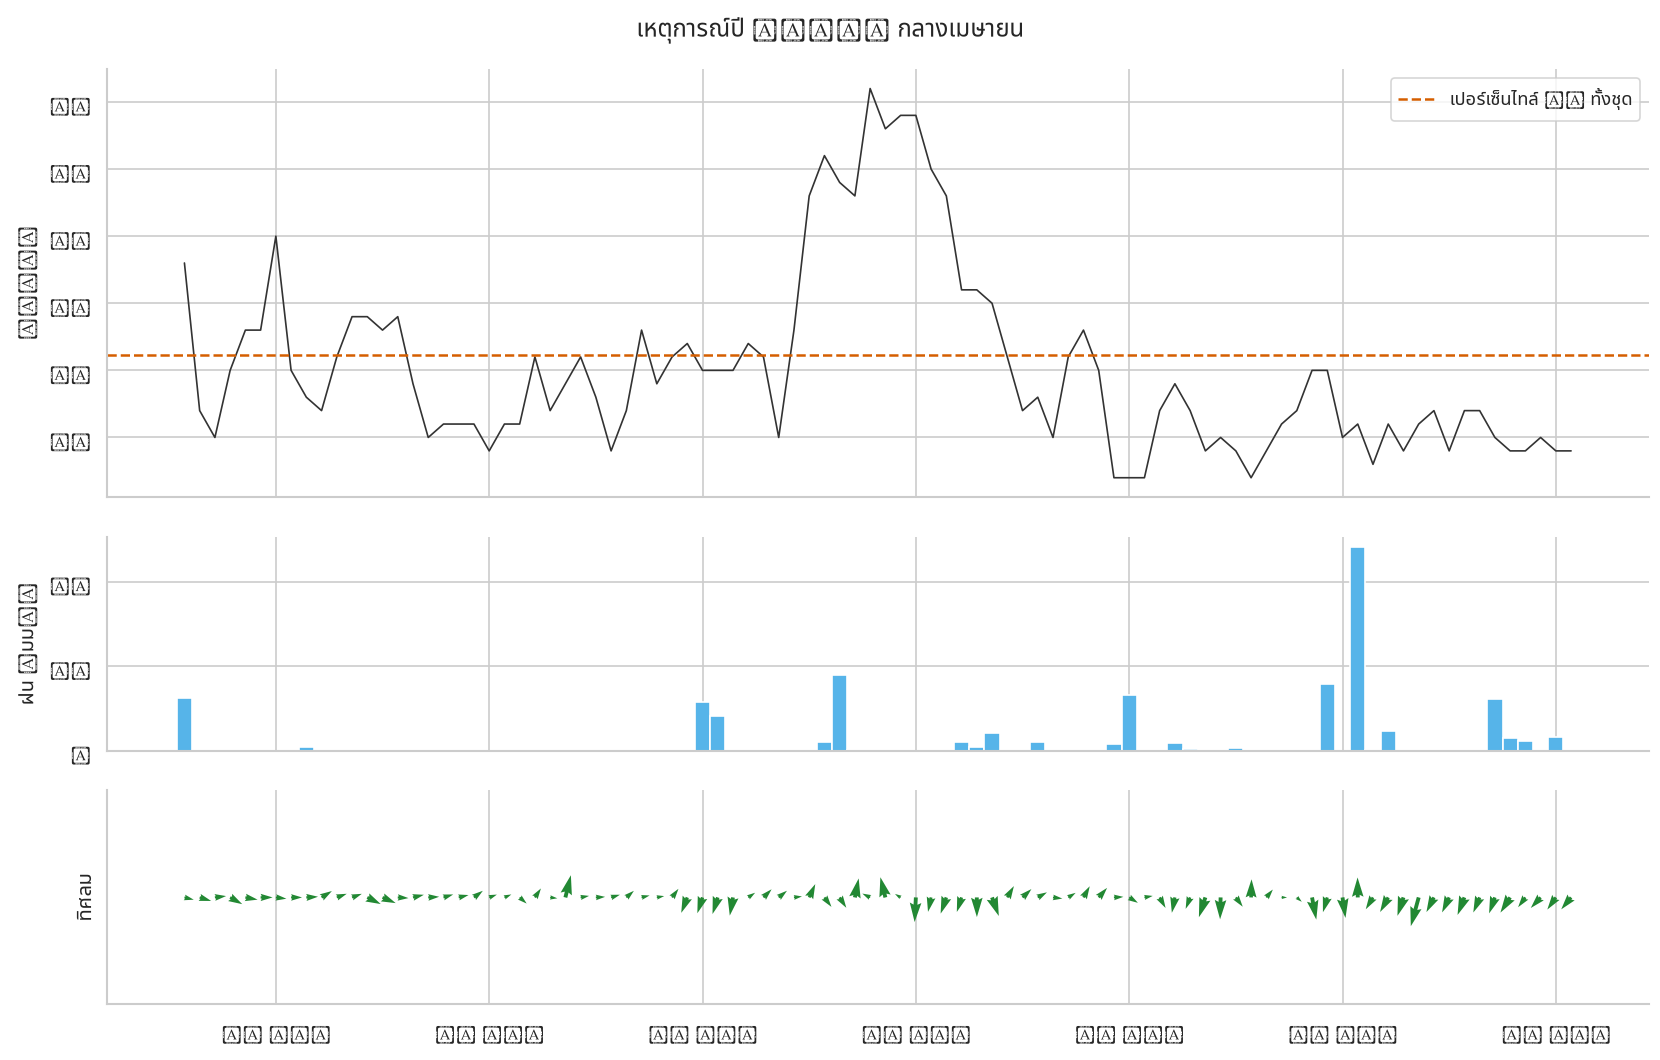

/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 80 (P) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 77 (M) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipy

บันทึก: /home/saktanuthpeak/art_of_com/figures/06_2023_03-01.png


/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 54 (6) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 40 (() missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 41 ()) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 65 (A) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 117 (u) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 103 (g) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 83 (S) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 101 (e) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/

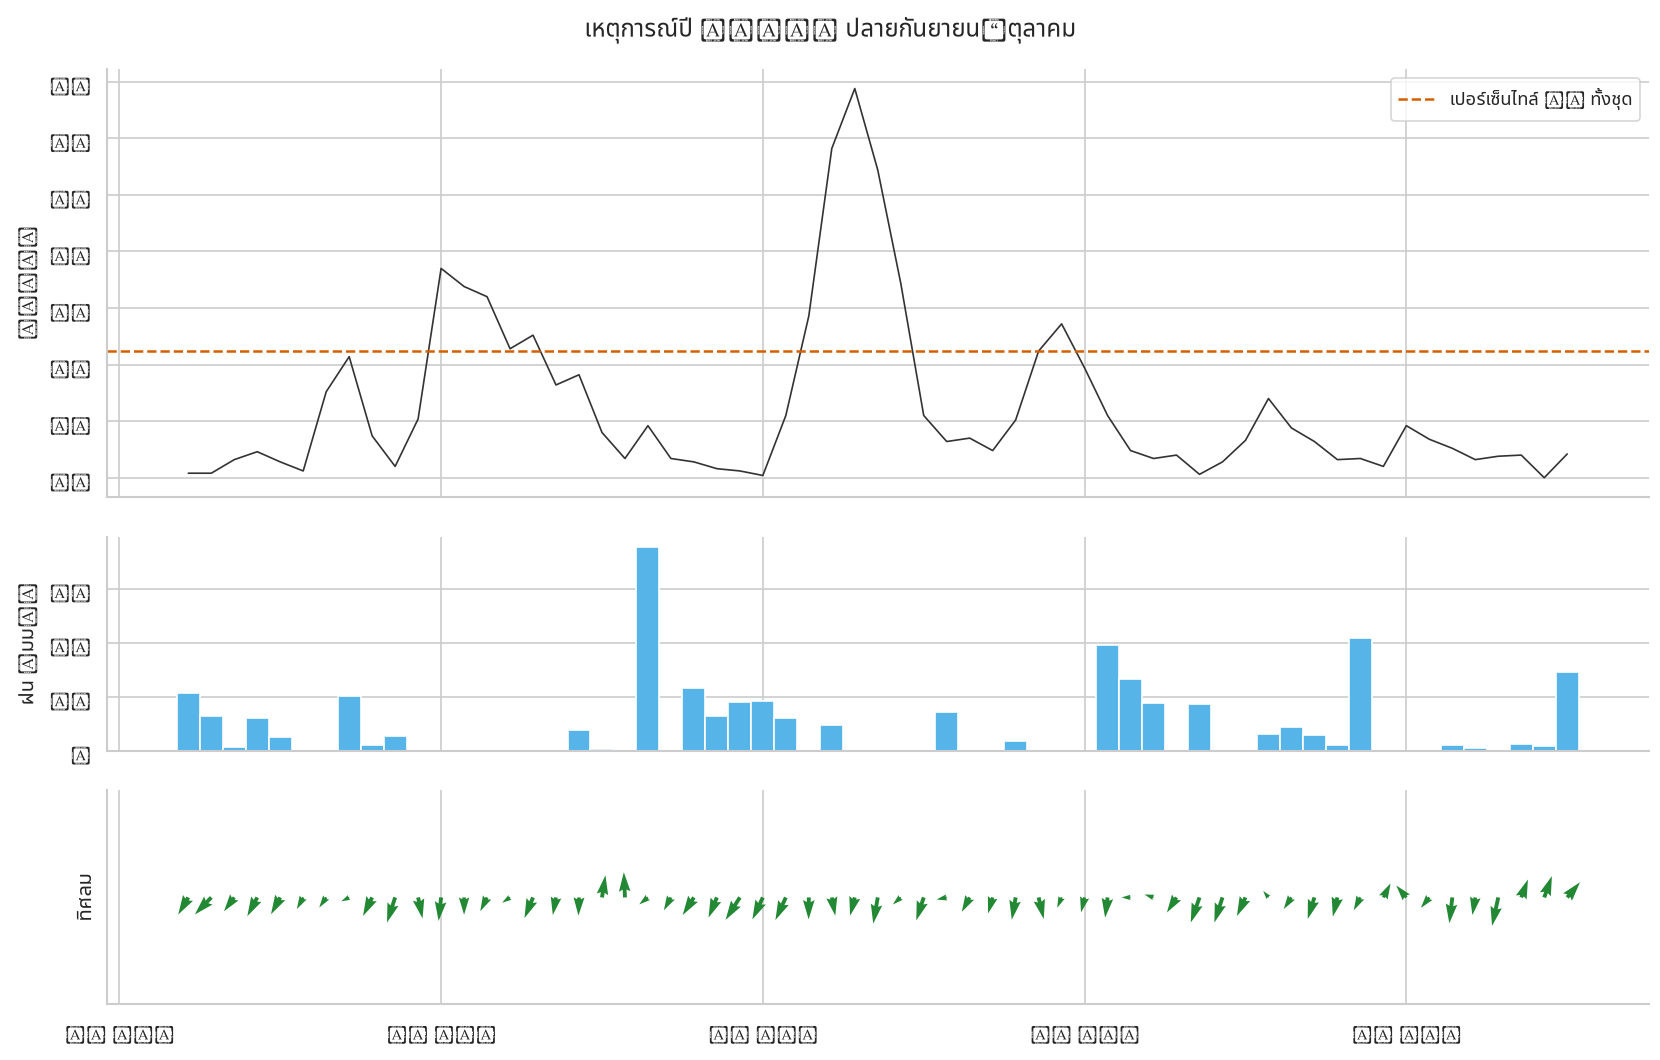

บันทึก: /home/saktanuthpeak/art_of_com/figures/06_2023_09-01.png


In [13]:
windows=[("กลางเมษายน", "2023-03-01", "2023-05-31"),("ปลายกันยายน–ตุลาคม", "2023-09-01", "2023-10-31")]
for title,start,end in windows:
    sub=df[df.date.between(start,end)].copy()
    fig,axes=plt.subplots(3,1,figsize=(14,9),sharex=True,gridspec_kw={"height_ratios":[2,1,1]})
    axes[0].plot(sub.date,sub.pm25,color="#333333",lw=1); axes[0].axhline(df.pm25.quantile(.90),ls="--",color="#D55E00",label="เปอร์เซ็นไทล์ 90 ทั้งชุด"); axes[0].set_ylabel("PM2.5"); axes[0].legend()
    axes[1].bar(sub.date,sub.rain_obs,color="#56B4E9",width=1); axes[1].set_ylabel("ฝน (มม.)")
    valid=sub.dropna(subset=["wind_dir","wind_max"]); theta=np.deg2rad(valid.wind_dir); u=np.sin(theta)*valid.wind_max; v=np.cos(theta)*valid.wind_max
    axes[2].quiver(valid.date, np.zeros(len(valid)), u, v, angles="xy", scale_units="xy", scale=30, width=.0025, color="#228833"); axes[2].set_ylim(-2,2); axes[2].set_yticks([]); axes[2].set_ylabel("ทิศลม")
    axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2)); axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%d %b")); fig.suptitle(f"เหตุการณ์ปี 2023: {title}")
    savefig(fig,"06_2023_"+start[5:] + ".png")


## 7. โมเดล Random Forest (ส่วนเสริม)

แบ่งตามเวลา: 2021–2024 สำหรับ train และ 2025 สำหรับ test ไม่มี `pm25_lag1` เพื่อไม่ให้ autocorrelation กลบความสำคัญของปัจจัยอื่น ผล importance เป็นความสำคัญเชิงพยากรณ์ ไม่ใช่เหตุและผล


Test 2025: R²=-0.898; MAE=5.74; n=349


/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 46 (.) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 80 (P) missing from font(s) Noto Sans Thai.
  fig.tight_la

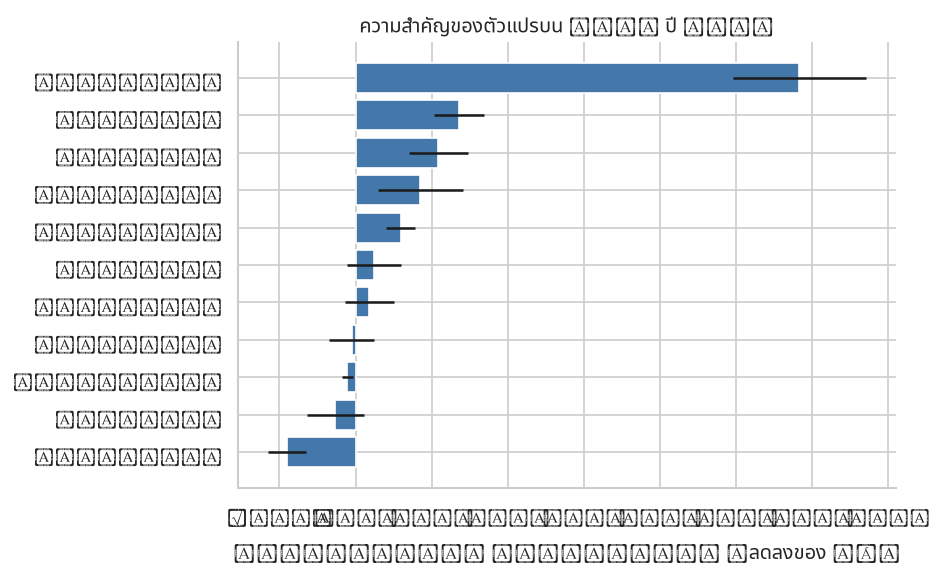

บันทึก: /home/saktanuthpeak/art_of_com/figures/07_1_permutation_importance.png


,feature,importance,std
8,month_sin,0.2917,0.0437
2,wind_sin,0.0680,0.0162
0,wind_max,0.0545,0.0195
5,rain_lag1,0.0426,0.0278
1,wind_gust,0.0296,0.0092
4,rain_obs,0.0122,0.0177
6,rain_lag2,0.0091,0.0161
7,rain_lag3,-0.0026,0.0149
10,is_holiday,-0.0054,0.0035
3,wind_cos,-0.0132,0.0188


In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error

model_df=df.copy()
model_df["month_sin"]=np.sin(2*np.pi*model_df.month/12); model_df["month_cos"]=np.cos(2*np.pi*model_df.month/12)
model_df["is_holiday"]=model_df.day_type.astype(str).str.contains("หยุด").astype(int)
model_features=["wind_max","wind_gust","wind_sin","wind_cos","rain_obs","rain_lag1","rain_lag2","rain_lag3","month_sin","month_cos","is_holiday"]
train=model_df[(model_df.year<2025)&model_df.pm25.notna()]; test=model_df[(model_df.year==2025)&model_df.pm25.notna()]
model=make_pipeline(SimpleImputer(strategy="median"),RandomForestRegressor(n_estimators=500,min_samples_leaf=3,max_features=.8,random_state=42,n_jobs=-1))
model.fit(train[model_features],train.pm25); pred=model.predict(test[model_features])
print(f"Test 2025: R²={r2_score(test.pm25,pred):.3f}; MAE={mean_absolute_error(test.pm25,pred):.2f}; n={len(test)}")
perm=permutation_importance(model,test[model_features],test.pm25,n_repeats=20,random_state=42,n_jobs=-1,scoring="r2")
imp=pd.DataFrame({"feature":model_features,"importance":perm.importances_mean,"std":perm.importances_std}).sort_values("importance")
fig,ax=plt.subplots(figsize=(8,5)); ax.barh(imp.feature,imp.importance,xerr=imp["std"],color=PALETTE[0]); ax.set(xlabel="Permutation importance (ลดลงของ R²)",title="ความสำคัญของตัวแปรบน test ปี 2025"); savefig(fig,"07_1_permutation_importance.png")
display(imp.sort_values("importance",ascending=False).round(4))


/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Noto Sans Thai.
  plt.tight_layout()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  plt.tight_layout()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  plt.tight_layout()
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 48 (0) mi

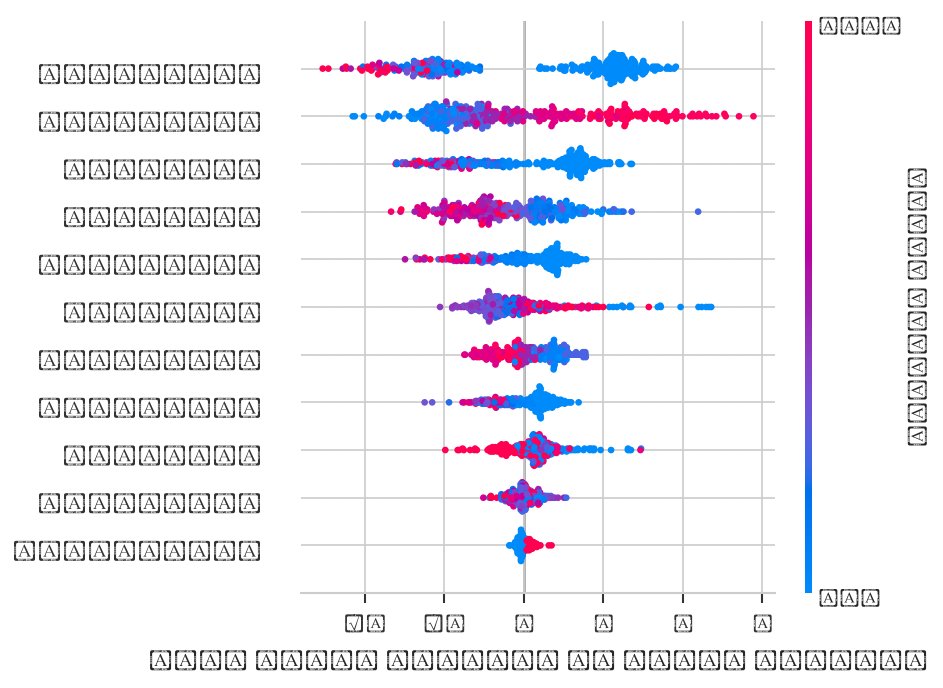

/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 114 (r) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 97 (a) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 105 (i) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/i

บันทึก: /home/saktanuthpeak/art_of_com/figures/07_2_shap_beeswarm.png


/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 103 (g) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:55: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.savefig(FIGURES / filename, dpi=200, bbox_inches="tight")
/tmp/ipykernel_127078/3497261289.py:55: UserWarning: Glyph 46 (.) missing from font(s) Noto Sans Thai.
  fig.savefig(FIGURES / filename, dpi=200, bbox_inches="tight")
/tmp/ipykernel_127078/3497261289.py:55: UserWarning: Glyph 102 (f) missing from font(s) Noto Sans Thai.
  fig.savefig(FIGURES / filename, dpi=200, bbox_inches="tight")
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Thai.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/art_of_com/notebooks/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 46 (.) missing from font(s) Noto 

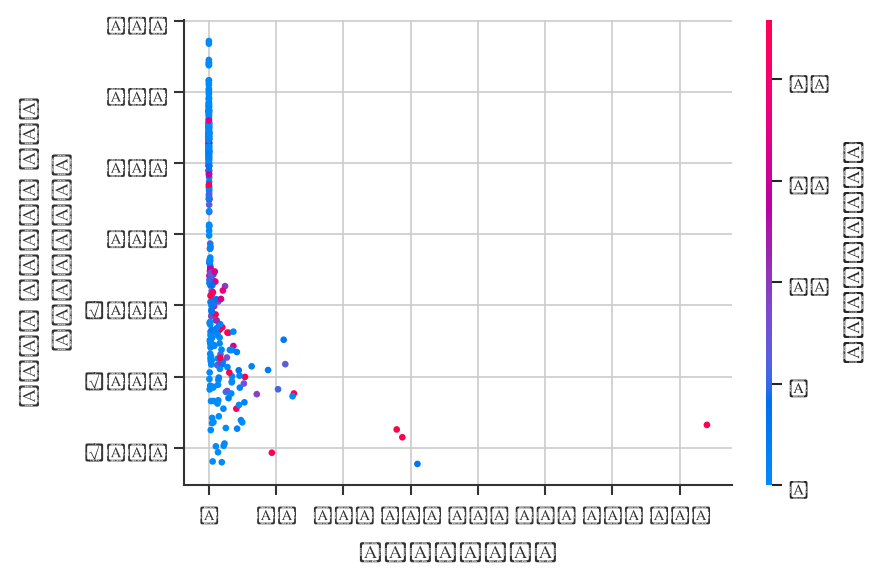

/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 55 (7) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 119 (w) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 100 (d) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 109 (m) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 116 (t) missing from font(s) Noto Sans Thai.
  fig.tight_layout()
/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 104 (h) missing from font(s) Noto Sans Thai.
  fig.tight_layout()


บันทึก: /home/saktanuthpeak/art_of_com/figures/07_3_shap_rain_obs.png


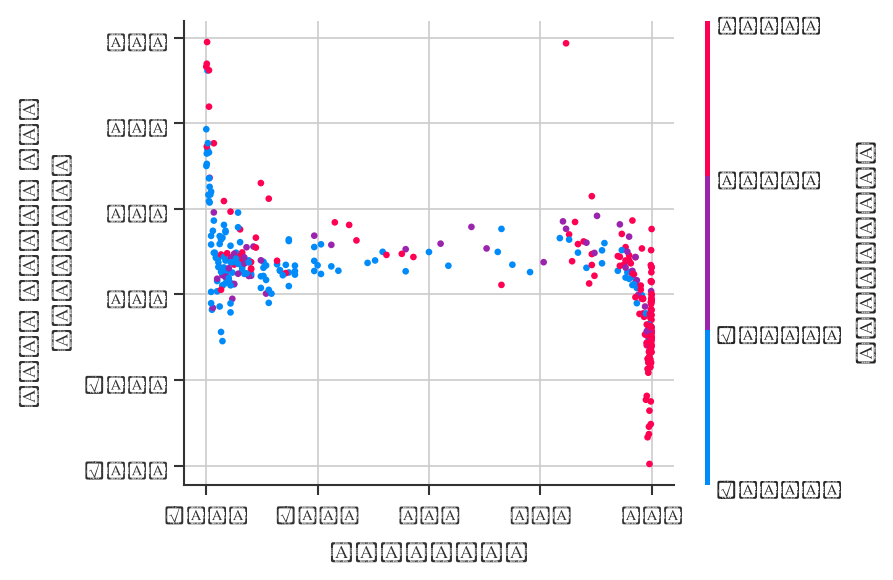

บันทึก: /home/saktanuthpeak/art_of_com/figures/07_3_shap_wind_sin.png


/tmp/ipykernel_127078/3497261289.py:54: UserWarning: Glyph 99 (c) missing from font(s) Noto Sans Thai.
  fig.tight_layout()


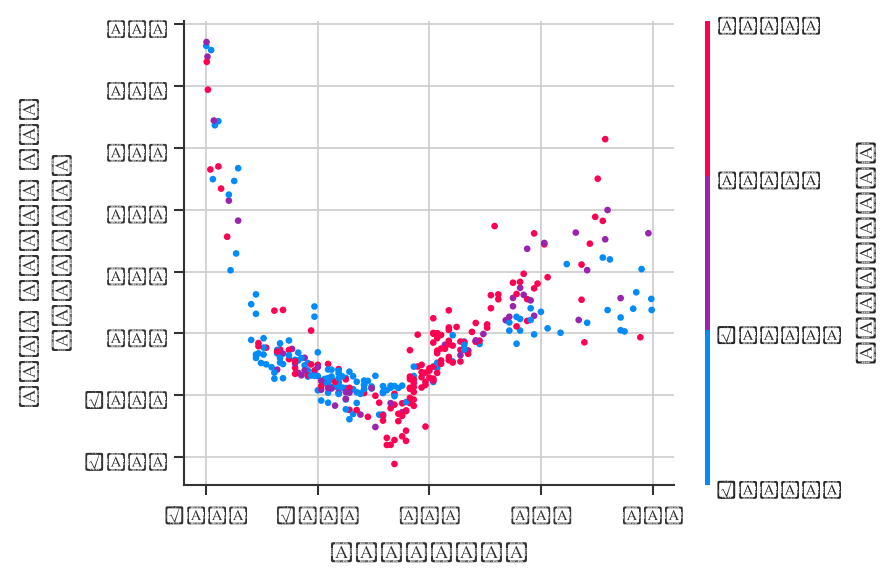

บันทึก: /home/saktanuthpeak/art_of_com/figures/07_3_shap_wind_cos.png


In [15]:
# SHAP เป็นส่วนเสริม ใช้ TreeExplainer กับ forest ภายใน pipeline
try:
    import shap
    forest=model.named_steps["randomforestregressor"]
    X_test_imp=model.named_steps["simpleimputer"].transform(test[model_features])
    explainer=shap.TreeExplainer(forest); shap_values=explainer.shap_values(X_test_imp)
    shap.summary_plot(shap_values,X_test_imp,feature_names=model_features,show=False); fig=plt.gcf(); savefig(fig,"07_2_shap_beeswarm.png")
    for name in ["rain_obs","wind_sin","wind_cos"]:
        shap.dependence_plot(name,shap_values,X_test_imp,feature_names=model_features,show=False); fig=plt.gcf(); savefig(fig,"07_3_shap_"+name+".png")
except ImportError:
    print("ข้าม SHAP: ติดตั้งเพิ่มด้วย `uv add shap` แล้วรันเซลล์นี้")


## 8. ขยายต่อ: อากาศย้อนหลังและ hotspot

เรียก Open-Meteo เมื่อกำหนด `RUN_OPEN_METEO=True` และมีอินเทอร์เน็ต โดยตัวอย่างนี้เพิ่มอุณหภูมิ/ความชื้นรายวัน และเฉลี่ยความสูงชั้นผสมอากาศจากข้อมูลรายชั่วโมง ตาม [เอกสาร Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api) (ข้อมูลจาก API อาจเปลี่ยนแปลงหรือไม่มีครบทุกวัน)


In [16]:
RUN_OPEN_METEO = False  # เปลี่ยนเป็น True เพื่อเรียก API
if RUN_OPEN_METEO:
    import requests
    params={"latitude":7.0084,"longitude":100.4747,"start_date":df.date.min().strftime("%Y-%m-%d"),"end_date":df.date.max().strftime("%Y-%m-%d"),"daily":"temperature_2m_mean,relative_humidity_2m_mean","hourly":"boundary_layer_height","timezone":"Asia/Bangkok"}
    response=requests.get("https://archive-api.open-meteo.com/v1/archive",params=params,timeout=60); response.raise_for_status()
    payload=response.json()
    weather_df=pd.DataFrame(payload["daily"]).rename(columns={"time":"date","temperature_2m_mean":"temp_mean","relative_humidity_2m_mean":"humidity_mean"})
    hourly=pd.DataFrame(payload["hourly"]).rename(columns={"time":"timestamp"})
    hourly["date"]=pd.to_datetime(hourly.timestamp).dt.date
    blh=hourly.groupby("date").boundary_layer_height.mean().rename("blh_mean").reset_index()
    weather_df["date"]=pd.to_datetime(weather_df.date)
    blh["date"]=pd.to_datetime(blh.date)
    weather_df=weather_df.merge(blh,on="date",how="left")
    df=df.merge(weather_df,on="date",how="left")
    display(df[["date","temp_mean","humidity_mean","blh_mean"]].head())
    # วิเคราะห์ต่อ: เพิ่มคอลัมน์เหล่านี้ใน corr_cols และ model_features แล้วรันเซลล์ 4/7 ใหม่
else:
    print("ข้ามการเรียก API; ตั้ง RUN_OPEN_METEO=True เพื่อดาวน์โหลดข้อมูล")


ข้ามการเรียก API; ตั้ง RUN_OPEN_METEO=True เพื่อดาวน์โหลดข้อมูล


### NASA FIRMS

การดึง hotspot จาก FIRMS ต้องใช้ MAP_KEY และกำหนดพื้นที่/ช่วงเวลาตามผลิตภัณฑ์ดาวเทียม แนะนำดาวน์โหลด CSV รายวันของภาคใต้ มาเลเซีย และสุมาตรา แล้วรวมจำนวนจุดตามวันที่ก่อน merge ด้วย `date` เพื่อหลีกเลี่ยงการฝัง secret key ลงใน notebook


## 9. สรุปผลที่คำนวณจากข้อมูล

ตัวเลขด้านล่างสร้างใหม่จากชีต Data เมื่อรันเซลล์นี้ ใช้เป็นสรุปเบื้องต้น และอ่านร่วมกับกราฟและข้อจำกัด


In [17]:
valid=df.dropna(subset=["pm25"])
annual_mean=valid.groupby("year").pm25.mean()
rain_r=spearmanr(df.pm25,df.rain_obs,nan_policy="omit").statistic
lag1_r=spearmanr(df.pm25,df.rain_lag1,nan_policy="omit").statistic
wet=df.loc[df.rain_obs>0,"pm25"].mean(); dry=df.loc[df.rain_obs==0,"pm25"].mean()
month_mean=valid.groupby("month").pm25.mean(); high_months=month_mean.nlargest(4).index.tolist(); low_months=month_mean.nsmallest(4).index.tolist()
peak=valid.loc[valid.pm25.idxmax()]
summary_lines = [
    f"• มีข้อมูล PM2.5 {len(valid):,} วัน จาก {len(df):,} วัน ({len(df)-len(valid)} วันไม่มีค่า)",
    f"• PM2.5 เฉลี่ย {valid.pm25.mean():.2f} และมัธยฐาน {valid.pm25.median():.1f} มคก./ลบ.ม.",
    f"• Spearman กับฝนวันเดียวกัน r={rain_r:.2f}; ฝนย้อนหลัง 1 วัน r={lag1_r:.2f}",
    f"• ค่าเฉลี่ยวันที่ฝนตก {wet:.2f} เทียบวันที่ฝนไม่ตก {dry:.2f} มคก./ลบ.ม.",
    f"• ปีแรก/ล่าสุด: {annual_mean.index.min():.0f}={annual_mean.iloc[0]:.2f}, {annual_mean.index.max():.0f}={annual_mean.iloc[-1]:.2f} มคก./ลบ.ม.",
    f"• เดือนค่าเฉลี่ยสูงสุดในชุดนี้: {high_months}; ต่ำสุด: {low_months}",
    f"• ค่าสูงสุด {peak.pm25:.1f} มคก./ลบ.ม. เมื่อ {peak.date.date()}"
]
print("\n".join(summary_lines))


• มีข้อมูล PM2.5 1,804 วัน จาก 1,826 วัน (22 วันไม่มีค่า)
• PM2.5 เฉลี่ย 14.93 และมัธยฐาน 14.3 มคก./ลบ.ม.
• Spearman กับฝนวันเดียวกัน r=-0.30; ฝนย้อนหลัง 1 วัน r=-0.35
• ค่าเฉลี่ยวันที่ฝนตก 13.43 เทียบวันที่ฝนไม่ตก 16.44 มคก./ลบ.ม.
• ปีแรก/ล่าสุด: 2021=16.68, 2025=10.99 มคก./ลบ.ม.
• เดือนค่าเฉลี่ยสูงสุดในชุดนี้: [4, 1, 3, 2]; ต่ำสุด: [11, 10, 9, 8]
• ค่าสูงสุด 44.4 มคก./ลบ.ม. เมื่อ 2023-09-30


### ข้อจำกัดในการตีความ

- มีข้อมูลจากสถานีเดียว และมีวันที่ขาดหาย 22 วันใน PM2.5/AQI ตามที่ระบุในแผน
- ยังไม่มีตัวแปรสำคัญบางส่วน เช่น อุณหภูมิ ความชื้น ความสูงชั้นผสมอากาศ และ hotspot (Open-Meteo เป็นส่วนเสริม)
- ความสัมพันธ์และความสำคัญของโมเดลไม่ได้ยืนยันสาเหตุ โดยเฉพาะสมมติฐานหมอกควันข้ามแดน
- ควรตรวจนิยาม/เวอร์ชันเกณฑ์ AQI ในชีต BP ก่อนเปรียบเทียบกับรายงานภายนอก
